In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Parameters

In [3]:
omega = 2.0
c = 0.5

t_min = 0.0
t_max = 10.0

x0 = 1.0
v0 = 0.0

N_col = 4000
epochs = 15000

Pinn Model

In [4]:
class PINN(nn.Module):
    def __init__(self, hidden=160):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )
        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

model = PINN().to(device)

Optimizer

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=25e-4)

In [6]:
t0_hat = torch.tensor([[0.0]], requires_grad=True, device=device)

Training

In [8]:
loss_history = []
print("Training started...")

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    t_col = torch.rand(N_col, 1, device=device) * (t_max - t_min) + t_min
    t_hat = t_col / t_max # Normalize to [0,1]
    t_hat.requires_grad_(True)

    x = model(t_hat)


    dx_dth = torch.autograd.grad(x, t_hat, grad_outputs=torch.ones_like(x), create_graph=True)[0]

    d2x_dth2 = torch.autograd.grad(dx_dth, t_hat, grad_outputs=torch.ones_like(dx_dth), create_graph=True)[0]

    dx_dt = dx_dth / t_max
    d2x_dt2 = d2x_dth2 / (t_max ** 2)

    damping = torch.sqrt(dx_dt ** 2 + 1e-6) * dx_dt

    # loss
    residual = d2x_dt2 + c * damping + (omega ** 2) * x
    loss_physics = torch.mean(residual ** 2)

    # Initial condition loss
    x_pred_0 = model(t0_hat)
    dx_dth_0 = torch.autograd.grad(x_pred_0, t0_hat, grad_outputs=torch.ones_like(x_pred_0), create_graph=True)[0]
    dx_dt_0 = dx_dth_0 / t_max
    loss_ic = (x_pred_0 - x0) ** 2 + (dx_dt_0 - v0) ** 2

    # Adaptive IC weight
    ic_weight = max(100.0 * (1 - epoch / 5000), 50.0)

    # Final Loss
    loss = (10.0 * loss_physics) + (ic_weight * loss_ic)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()


    loss_history.append(loss.item())

    if epoch % 1000 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4e} | Physics: {loss_physics.item():.4e} | IC: {loss_ic.item():.4e}")

print("Training complete.")


Training started...
Epoch     1 | Loss: 2.0221e+02 | Physics: 1.2675e+01 | IC: 7.5477e-01
Epoch  1000 | Loss: 6.9552e-01 | Physics: 5.5040e-02 | IC: 1.8141e-03
Epoch  2000 | Loss: 3.4681e-01 | Physics: 2.4058e-02 | IC: 1.7705e-03
Epoch  3000 | Loss: 2.5500e-01 | Physics: 1.8326e-02 | IC: 1.4349e-03
Epoch  4000 | Loss: 1.9949e-01 | Physics: 1.4877e-02 | IC: 1.0142e-03
Epoch  5000 | Loss: 1.8754e-01 | Physics: 1.5900e-02 | IC: 5.7083e-04
Epoch  6000 | Loss: 2.8574e-01 | Physics: 2.6128e-02 | IC: 4.8918e-04
Epoch  7000 | Loss: 2.3438e-01 | Physics: 2.0173e-02 | IC: 6.5302e-04
Epoch  8000 | Loss: 1.5508e-01 | Physics: 9.4502e-03 | IC: 1.2116e-03
Epoch  9000 | Loss: 2.8668e-01 | Physics: 1.3556e-02 | IC: 3.0224e-03
Epoch 10000 | Loss: 4.4087e-01 | Physics: 2.4906e-02 | IC: 3.8361e-03
Epoch 11000 | Loss: 5.2014e-02 | Physics: 3.7313e-03 | IC: 2.9400e-04
Epoch 12000 | Loss: 5.7870e-02 | Physics: 9.4104e-04 | IC: 9.6920e-04
Epoch 13000 | Loss: 5.1939e-02 | Physics: 8.3059e-04 | IC: 8.7266e-04


Reference Model (Runge-Kutta Method)

In [9]:
def nonlinear_oscillator(t, y):
    x, v = y
    dxdt = v
    dvdt = -c * abs(v) * v - (omega ** 2) * x
    return np.array([dxdt, dvdt])

def rk4(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(len(t) - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + dt/2, y[i] + dt*k1/2)
        k3 = f(t[i] + dt/2, y[i] + dt*k2/2)
        k4 = f(t[i] + dt, y[i] + dt*k3)
        y[i+1] = y[i] + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    return y

t_test = np.linspace(t_min, t_max, 500)
sol = rk4(nonlinear_oscillator, np.array([x0, v0]), t_test)
x_true = sol[:, 0]

Prediction

In [10]:
t_test_tensor = torch.tensor(t_test / t_max, dtype=torch.float32).view(-1, 1).to(device)
with torch.no_grad():
    x_pred = model(t_test_tensor).cpu().numpy().flatten()

Error Matrices

In [11]:
error = np.abs(x_true - x_pred)
mse = np.mean((x_true - x_pred) ** 2)
rel_error = np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)

print(f"\nMSE: {mse:.4e}")
print(f"Relative Error: {rel_error:.4e}")
print(f"Max Error: {np.max(error):.4e}")


MSE: 7.8579e-04
Relative Error: 8.6550e-02
Max Error: 5.9703e-02


Plots

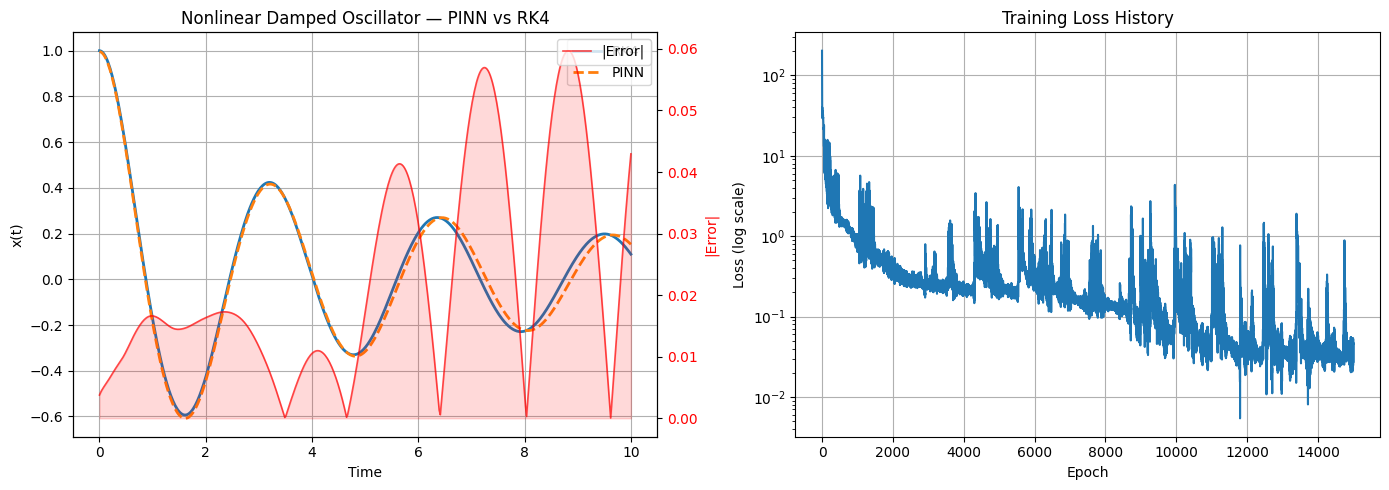

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solution comparison
ax = axes[0]
ax.plot(t_test, x_true, lw=2, label="RK4")
ax.plot(t_test, x_pred, '--', lw=2, label="PINN")
ax.set_xlabel("Time")
ax.set_ylabel("x(t)")
ax.set_title("Nonlinear Damped Oscillator — PINN vs RK4")
ax.legend()
ax.grid(True)

# Error overlay
ax2 = ax.twinx()
ax2.plot(t_test, error, color='red', lw=1.2, alpha=0.7, label="|Error|")
ax2.fill_between(t_test, error, color='red', alpha=0.15)
ax2.set_ylabel("|Error|", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc="upper right")

# Loss history
axes[1].semilogy(loss_history)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log scale)")
axes[1].set_title("Training Loss History")
axes[1].grid(True)

plt.tight_layout()
plt.show()